<a href="https://colab.research.google.com/github/Tysenxw/inst414-network-analysis-Module1/blob/main/Module_1_wills%2CTysen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import json
import zipfile
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load JSON data
with zipfile.ZipFile('/content/output.json.zip', 'r') as zip_file:
    with zip_file.open('output.json') as file:
        data = json.load(file)

print(f"Total entries: {len(data)}")


# 2. Create a post 1940 subset
subset = []

for entry in data:
    dob = entry.get("dob")

    # Only values where dob has a birth year
    if dob and dob[0] is not None:
        birth_year = dob[0]

        if birth_year > 1940:
            subset.append(entry)

print(f"Entries born after 1940: {len(subset)}")


# VALIDATION: Checking birth-year filter
birth_years = [entry["dob"][0] for entry in subset]

print("Minimum birth year:", min(birth_years))
print("Any people born in 1940 or earlier:",
      any(year <= 1940 for year in birth_years))


# 3. subset
subset_names = set()

for entry in subset:
    subset_names.add(entry["name"])


# 4. Graph Definition
G = nx.DiGraph()

for entry in subset:
    person = entry["name"]
    birth_year = entry["dob"][0]

    # Add the person as a node
    G.add_node(person, birth_year=birth_year)

    # Add edges (links)
    for target in entry.get("links", []):
        if target in subset_names:
            G.add_edge(person, target)


# VALIDATION 2: Check graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


# 5. Calculate in-degree
# In-degree = number of incoming links
in_degrees = dict(G.in_degree())


# 6. Calculate PageRank
pagerank_scores = nx.pagerank(G)


# 7. Put the results into one DataFrame
results = []

for person in G.nodes():
    results.append({
        "historical figure": person,
        "birth year": G.nodes[person]["birth_year"],
        "In-Degree": in_degrees[person],
        "PageRank": pagerank_scores[person]
    })

df_results = pd.DataFrame(results)


# 8. Find the top 10 based on In-Degree
highest_indegree = df_results.sort_values(
    by="In-Degree",
    ascending=False
).head(10)

print("TOP 10 BY IN-DEGREE")
print(highest_indegree.to_string(index=False))


# 9. Find the top 10 based on PageRank
highest_pagerank = df_results.sort_values(
    by="PageRank",
    ascending=False
).head(10)

print("TOP 10 BY PAGERANK")
print(highest_pagerank.to_string(index=False))



Total entries: 1259410
Entries born after 1940: 758388
Minimum birth year: 1941
Any people born in 1940 or earlier: False


Sample nodes: 100
Sample edges: 117


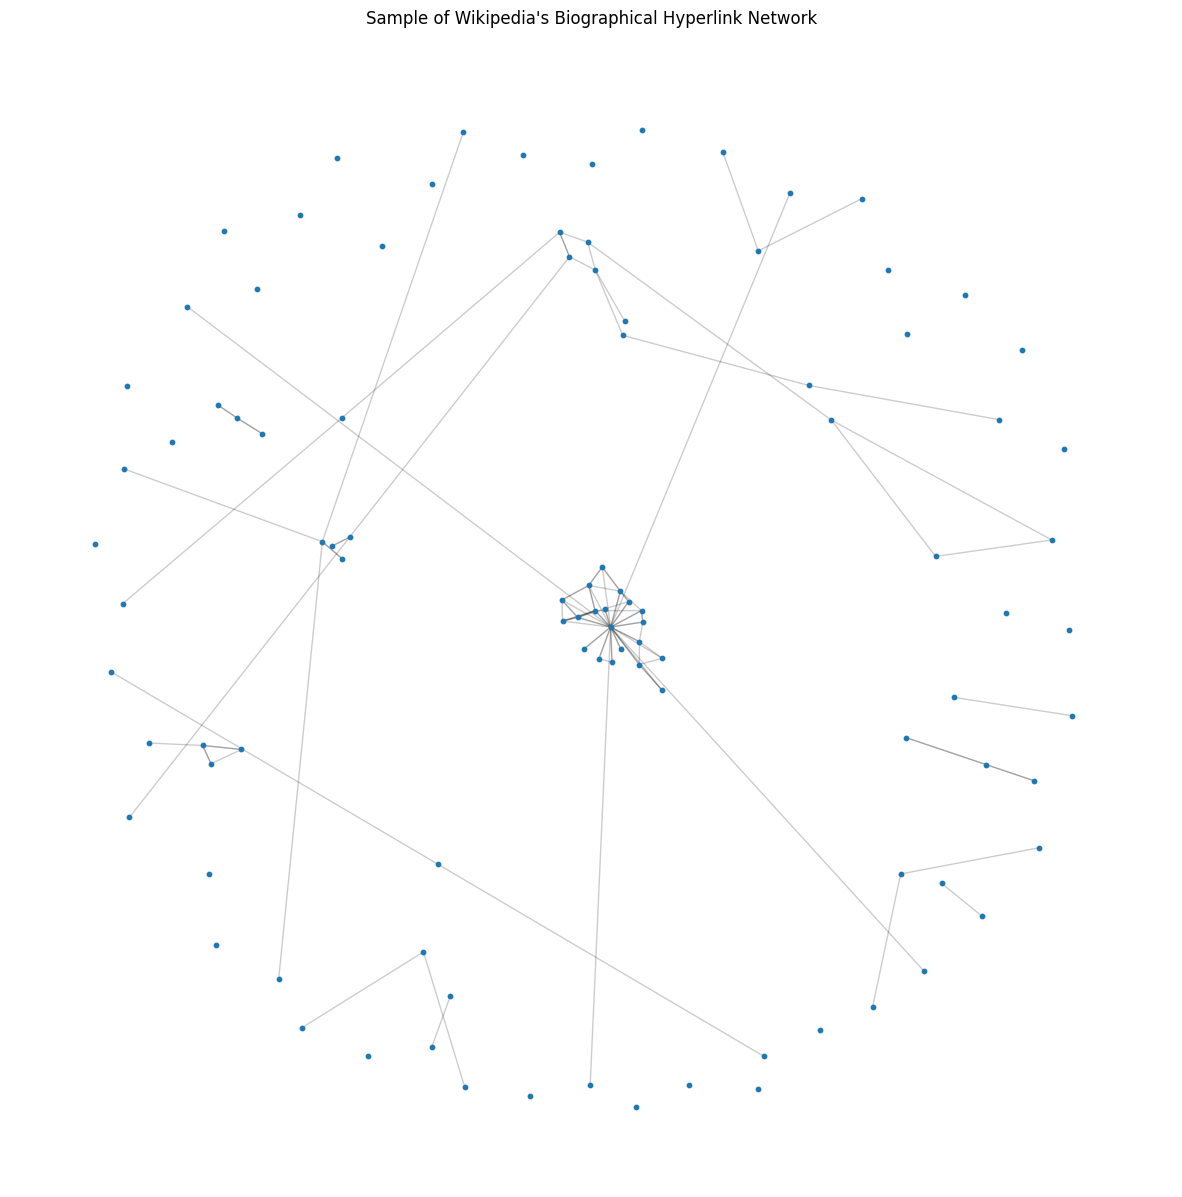

In [7]:
# Take top 100 nodes from the network
sample_nodes = list(G.nodes())[:100]

# Create a smaller graph for visualization
G_sample = G.subgraph(sample_nodes).copy()

# Create the layout
pos = nx.spring_layout(G_sample, seed=40)

# Draw the graph
plt.figure(figsize=(15, 15))

nx.draw_networkx_nodes(
    G_sample,
    pos,
    node_size=10
)

nx.draw_networkx_edges(
    G_sample,
    pos,
    arrows=False,
    alpha=0.2
)

plt.title("Top 10 individuals within Wikipedia's Biographical Hyperlink Network")
plt.axis("off")
plt.show()

In [ ]:
# Validation

print(df_filtered.head(10))